# Human SAN — Spontaneous Spiking with Rate-Addend Forcing

Compiles the Fabbri-Fantini-Wilders-Severi 2017 human sinoatrial-node model
and integrates it from the published initial conditions.  Time is in seconds.

The SAN is intrinsically self-oscillatory — no external stimulus is needed.
Here the model is compiled with a `rate_addend` override on `V_ode` so that
an arbitrary waveform can be added directly to `dV/dt` at every solver step:

$$\frac{dV}{dt}\bigg|_{\text{total}} = \frac{dV}{dt}\bigg|_{\text{model}} + f(t)$$

`V_ode` is in mV and time is in s, so `f(t)` is in mV/s.
The baseline `dV/dt` during diastolic depolarisation is ~60–100 mV/s, so
addends in the range ±50–200 mV/s produce a clearly visible change in beat rate.
To convert from a physical injection current:
$$f\ [\text{mV/s}] = \frac{I_{\text{inj}}\ [\text{pA}]}{C_m\ [\text{pF}]} \times 1000
\qquad (C_m \approx 57\,\text{pF}\ \text{for the Fabbri SAN})$$

The default demo uses a ramp that sweeps from `ramp_i_start` to `ramp_i_end`
over the simulation window, progressively accelerating the pacemaker rate.

Step through the cells in order.  Edit any settings cell and re-run from there.


In [1]:
import sys
import pathlib
import numpy as np

_root = next(
    p
    for p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]
    if (p / "src" / "cellml2py").exists()
)
# for _p in [str(_root / "src"), str(_root / "examples")]:
#     if _p not in sys.path:
#         sys.path.insert(0, _p)

In [2]:
from cellml2py import CompileOptions, OverrideSpec, compile_cellml, simulate
from example_utils import build_injection_current, plot_voltage_and_current


In [3]:
# --- compile with rate_addend override on membrane voltage ---
model_path = _root / "data/HumanSAN_Fabbri_Fantini_Wilders_Severi_2017.cellml"

options = CompileOptions(
    override_targets=(OverrideSpec(target="V_ode", kind="rate_addend"),)
)
model = compile_cellml(model_path, backend="numpy", options=options)
print(
    f"compiled  states={model.initial_state.size}  forcing={model.layout.forcing_names}"
)


compiled  states=33  forcing=('V_ode',)


In [4]:
# --- forcing settings ---
# forcing_mode: 'ramp', 'constant', or 'pulse'
forcing_mode = "ramp"

# ramp: linearly sweeps from ramp_i_start to ramp_i_end over [ramp_start, ramp_end]
# Units: mV/s added to dV/dt  (V_ode is in mV, time in s).
# Baseline dV/dt is ~60-100 mV/s, so values of ±50-200 mV/s are clearly visible.
# Equivalent physical current: I_inj [pA] = addend [mV/s] * C_m [pF] / 1000
#   e.g. 100 mV/s * 57 pF / 1000 = 5.7 pA
ramp_start = 0.0  # s — time the ramp begins
ramp_end = 4.0  # s — time the ramp ends  (set equal to t_end to span full sim)
ramp_i_start = 0.0  # mV/s addend at ramp_start
ramp_i_end = 100.0  # mV/s addend at ramp_end  (~5.7 pA equivalent)

# constant / pulse fallback settings (unused when forcing_mode = 'ramp')
constant_current = 0.0
amp = 100.0  # mV/s
pulse_start = 0.5
pulse_width = 0.05
pulse_interval = 0.8
n_pulses = 2

i_inj = build_injection_current(
    forcing_mode,
    constant_current,
    amp,
    pulse_start,
    pulse_width,
    pulse_interval,
    n_pulses,
    ramp_start=ramp_start,
    ramp_end=ramp_end,
    ramp_i_start=ramp_i_start,
    ramp_i_end=ramp_i_end,
)


In [5]:
# --- solver settings ---
t_end = 4.0  # s  (covers ~2 spontaneous beats)
steps = 1001
method = "Radau"
max_step = 0.01  # s  — required for stability with the stiff SAN model

sol = simulate(
    model,
    (0.0, t_end),
    steps=steps,
    forcing=lambda t: [i_inj(t)],
    method=method,
    max_step=max_step,
)
print(f"success={sol.success}   samples={sol.t.size}   message: {sol.message}")


success=True   samples=1001   message: The solver successfully reached the end of the integration interval.


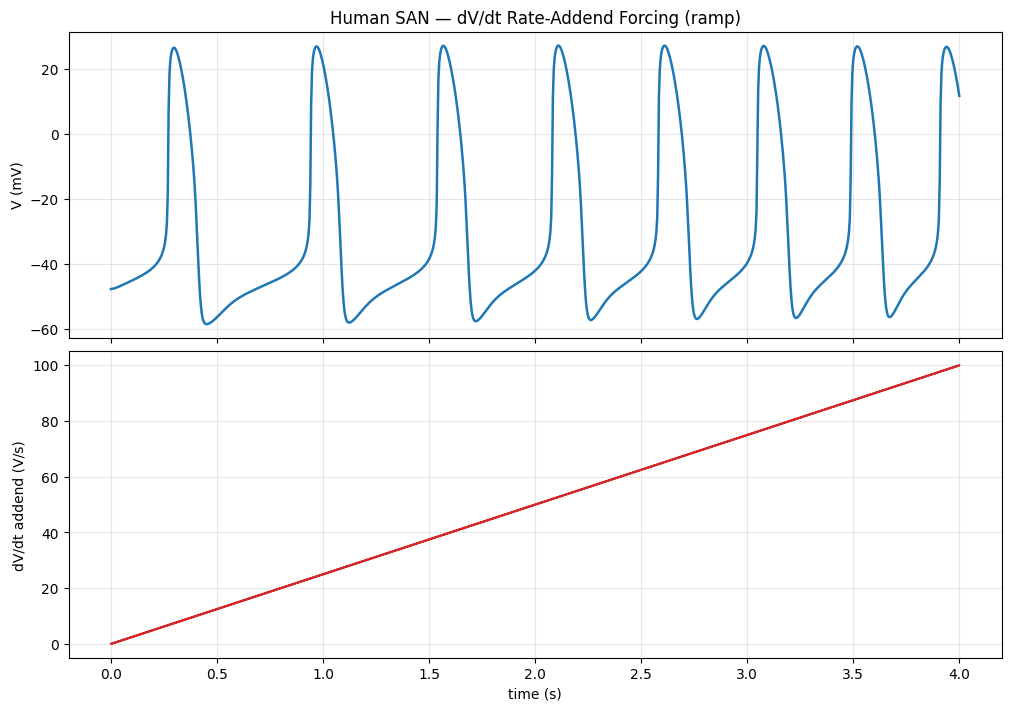

WindowsPath('san_spiking_forced.png')

In [6]:
current_trace = np.array([i_inj(float(t)) for t in sol.t])

plot_voltage_and_current(
    sol.t,
    sol.y[0],
    current_trace,
    title="Human SAN — dV/dt Rate-Addend Forcing (ramp)",
    time_label="time (s)",
    current_label="dV/dt addend (V/s)",
    plot_path="san_spiking_forced.png",
    show=True,
)
